In [ ]:
import os

os.makedirs("results", exist_ok=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


API_CONFIGS = {
    "gpt-4o-mini": {"provider": "openai", "model": "gpt-4o-mini"},
    "claude-haiku": {"provider": "anthropic", "model": "claude-haiku-4-5-20251001"},
    "gemini-flash": {"provider": "google", "model": "gemini-2.5-flash-lite"},
}

TASK_TEMPLATES = [
    {"query": "best noise-canceling headphones 2025", "expected_keywords": ["sony", "bose", "apple", "airpods", "wh-1000xm5"]},
    {"query": "top programming languages 2025", "expected_keywords": ["python", "javascript", "rust", "typescript", "go"]},
    {"query": "healthy breakfast recipes quick", "expected_keywords": ["oatmeal", "eggs", "smoothie", "yogurt", "avocado"]},
]


def call_api(model_name, prompt):
    cfg = API_CONFIGS[model_name]

    if cfg["provider"] == "openai":
        from openai import OpenAI
        client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
        r = client.chat.completions.create(model=cfg["model"], messages=[{"role": "user", "content": prompt}], max_tokens=512)
        return r.choices[0].message.content

    elif cfg["provider"] == "anthropic":
        import anthropic
        client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
        r = client.messages.create(model=cfg["model"], max_tokens=512, messages=[{"role": "user", "content": prompt}])
        return r.content[0].text

    elif cfg["provider"] == "google":
        import google.generativeai as genai
        genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
        m = genai.GenerativeModel(cfg["model"])
        return m.generate_content(prompt).text


def run_workflow(model_name, query, error_step=None):
    outputs = []
    current = query

    prompts = [
        lambda q: f"You are a search engine. Return 5 relevant results for: '{q}'. Format: numbered list.",
        lambda q: f"Filter to top 3 most relevant:\n\n{q}",
        lambda q: f"Summarize key information:\n\n{q}",
        lambda q: f"Write a recommendation paragraph:\n\n{q}",
    ]

    for i in range(4):
        output = call_api(model_name, prompts[i](current))
        if error_step == i:
            output = output.replace("2025", "2019").replace("best", "worst")
        outputs.append(output)
        current = output


    verify_prompt = f"Verify if this addresses '{query}':\n\n{current}\n\nRespond VALID or INVALID."
    output = call_api(model_name, verify_prompt)
    if error_step == 4:
        output = output.replace("VALID", "INVALID")
    outputs.append(output)

    return outputs


def evaluate(outputs, keywords):
    final = outputs[-1]
    is_valid = "VALID" in final.upper()
    kw_score = sum(1 for k in keywords if k.lower() in outputs[-2].lower()) / len(keywords)
    return {"is_valid": is_valid, "keyword_score": kw_score, "combined": 0.5 * int(is_valid) + 0.5 * kw_score}

import json
from tqdm import tqdm
from datetime import datetime

def run_experiment(model_name, num_trials=50):
    results = []
    total = len(TASK_TEMPLATES) * 6 * num_trials

    with tqdm(total=total, desc=model_name) as pbar:
        for task in TASK_TEMPLATES:
            for error_step in [None, 0, 1, 2, 3, 4]:
                for trial in range(num_trials):
                    try:
                        outputs = run_workflow(model_name, task["query"], error_step)
                        ev = evaluate(outputs, task["expected_keywords"])
                        results.append({"task": task["query"], "error_step": error_step, "trial": trial, "evaluation": ev})
                    except Exception as e:
                        results.append({"task": task["query"], "error_step": error_step, "trial": trial, "error": str(e)})
                    pbar.update(1)

    filename = f"results/{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(filename, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved: {filename}")
    return results


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.8 MB/s eta 0:00:00


In [3]:
results_gemini = run_experiment("gemini-flash", num_trials=50)
results_claude = run_experiment("claude-haiku", num_trials=50)
results_openai = run_experiment("gpt-4o-mini", num_trials=50)

from google.colab import files
import glob
for f in glob.glob("results/*.json"):
    files.download(f)

gemini-flash:   0%|          | 0/900 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
gemini-flash: 100%|██████████| 900/900 [02:38<00:00,  5.66it/s]


Saved: results/gemini-flash_20260309_201729.json


claude-haiku: 100%|██████████| 900/900 [02:30<00:00,  5.98it/s]


Saved: results/claude-haiku_20260309_202000.json


gpt-4o-mini: 100%|██████████| 900/900 [3:55:55<00:00, 15.73s/it]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
results_gemini = run_experiment("gemini-flash", num_trials=30)

gemini-flash: 100%|██████████| 540/540 [01:30<00:00,  5.98it/s]

Saved: results/gemini-flash_20260310_011819.json


In [18]:
results_claude = run_experiment("claude-haiku", num_trials=30)

claude-haiku: 100%|██████████| 540/540 [1:36:15<00:00, 10.70s/it]

Saved: results/claude-haiku_20260310_030151.json


Loaded 1439 results from 2 models

=== Failure Rates ===
          model  error_step  baseline  score  degradation
0   gpt-4o-mini           0     0.714  0.670        0.062
1   gpt-4o-mini           1     0.714  0.711        0.005
2   gpt-4o-mini           2     0.714  0.714       -0.000
3   gpt-4o-mini           3     0.714  0.685        0.040
4   gpt-4o-mini           4     0.714  0.721       -0.010
5  claude-haiku           0     0.823  0.762        0.074
6  claude-haiku           1     0.823  0.819        0.005
7  claude-haiku           2     0.823  0.798        0.031
8  claude-haiku           3     0.823  0.847       -0.028
9  claude-haiku           4     0.823  0.819        0.005

=== Generating Plots ===


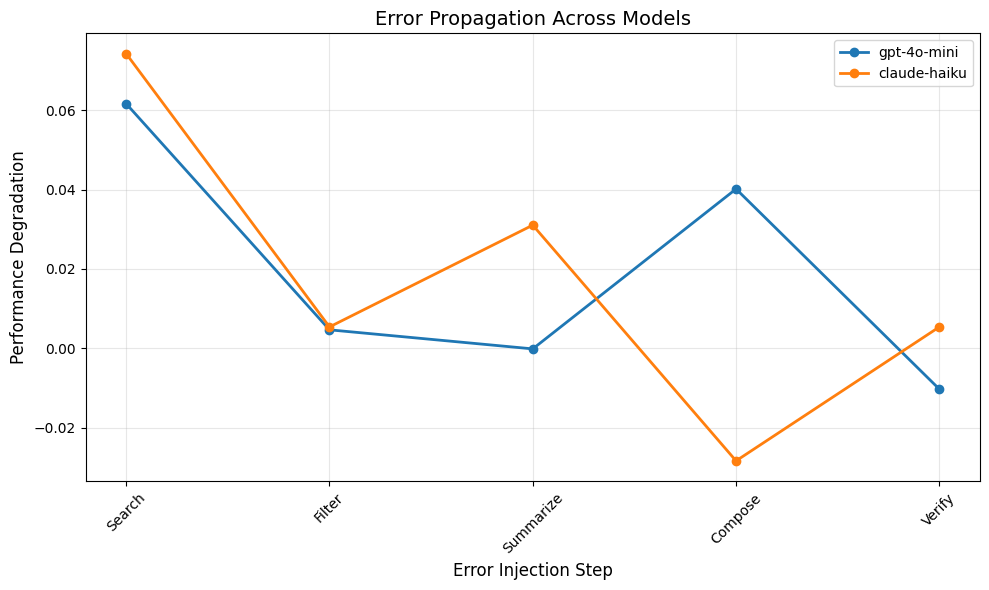

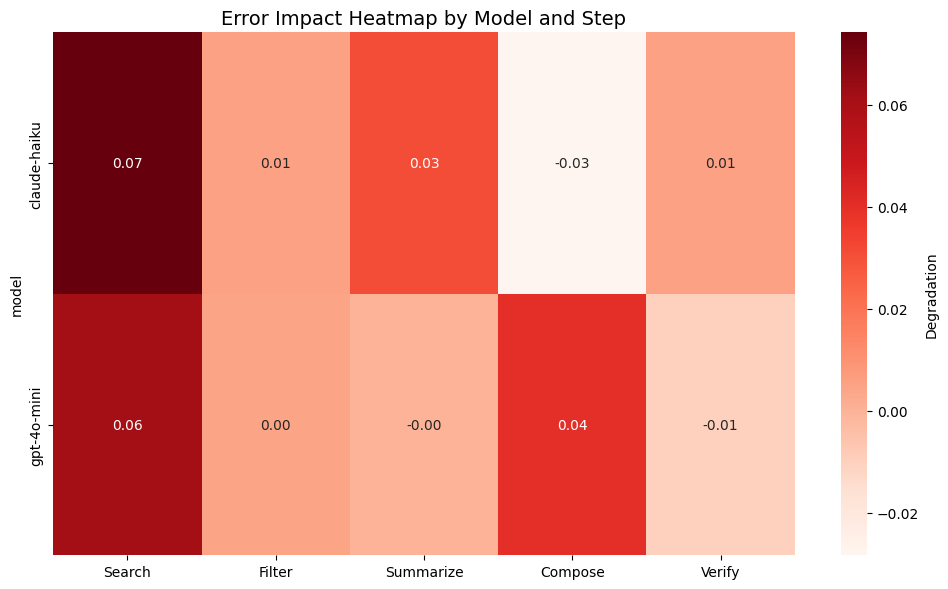


=== Pattern Analysis ===
          model      pattern  rmse_exp  rmse_lin
0   gpt-4o-mini  exponential  0.018521  0.022446
1  claude-haiku  exponential  0.018649  0.023907

=== Critical Steps ===
          model  error_step  degradation
5  claude-haiku           0     0.074224
0   gpt-4o-mini           0     0.061625


In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
import glob

def load_all_results(results_dir="results"):
    all_data = []
    for f in glob.glob(f"{results_dir}/*.json"):
        model_name = f.split("/")[-1].split("_")[0]
        with open(f) as file:
            data = json.load(file)
            for d in data:
                if "error" not in d:
                    d["model"] = model_name
                    all_data.append(d)
    return pd.DataFrame(all_data)

def compute_failure_rates(df):
    results = []
    for model in df["model"].unique():
        model_df = df[df["model"] == model]
        baseline = model_df[model_df["error_step"].isna()]["evaluation"].apply(lambda x: x["combined"]).mean()

        for step in range(5):
            step_df = model_df[model_df["error_step"] == step]
            if len(step_df) == 0:
                continue
            step_score = step_df["evaluation"].apply(lambda x: x["combined"]).mean()
            degradation = (baseline - step_score) / baseline if baseline > 0 else 0
            results.append({
                "model": model,
                "error_step": step,
                "baseline": baseline,
                "score": step_score,
                "degradation": degradation,
            })
    return pd.DataFrame(results)

def plot_error_propagation(failure_df, output_path="figures/error_propagation.png"):
    plt.figure(figsize=(10, 6))
    step_names = ["Search", "Filter", "Summarize", "Compose", "Verify"]

    for model in failure_df["model"].unique():
        model_df = failure_df[failure_df["model"] == model].sort_values("error_step")
        plt.plot(model_df["error_step"], model_df["degradation"], marker="o", label=model, linewidth=2)

    plt.xlabel("Error Injection Step", fontsize=12)
    plt.ylabel("Performance Degradation", fontsize=12)
    plt.title("Error Propagation Across Models", fontsize=14)
    plt.xticks(range(5), step_names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

def plot_heatmap(failure_df, output_path="figures/heatmap.png"):
    pivot = failure_df.pivot(index="model", columns="error_step", values="degradation")
    pivot.columns = ["Search", "Filter", "Summarize", "Compose", "Verify"]

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "Degradation"})
    plt.title("Error Impact Heatmap by Model and Step", fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

def fit_decay_patterns(failure_df):
    def exp_decay(x, a, b):
        return a * np.exp(-b * x)

    def linear_decay(x, a, b):
        return a - b * x

    results = []
    for model in failure_df["model"].unique():
        model_df = failure_df[failure_df["model"] == model].sort_values("error_step")
        x = model_df["error_step"].values.astype(float)
        y = model_df["degradation"].values

        try:
            popt_exp, _ = curve_fit(exp_decay, x, y, p0=[0.5, 0.3], maxfev=5000)
            rmse_exp = np.sqrt(np.mean((y - exp_decay(x, *popt_exp)) ** 2))
        except:
            rmse_exp = float("inf")

        try:
            popt_lin, _ = curve_fit(linear_decay, x, y, p0=[0.5, 0.1], maxfev=5000)
            rmse_lin = np.sqrt(np.mean((y - linear_decay(x, *popt_lin)) ** 2))
        except:
            rmse_lin = float("inf")

        pattern = "exponential" if rmse_exp < rmse_lin else "linear"
        results.append({"model": model, "pattern": pattern, "rmse_exp": rmse_exp, "rmse_lin": rmse_lin})

    return pd.DataFrame(results)

def generate_report():
    import os
    os.makedirs("figures", exist_ok=True)

    df = load_all_results()
    print(f"Loaded {len(df)} results from {df['model'].nunique()} models")

    failure_df = compute_failure_rates(df)
    print("\n=== Failure Rates ===")
    print(failure_df.round(3))

    print("\n=== Generating Plots ===")
    plot_error_propagation(failure_df)
    plot_heatmap(failure_df)

    print("\n=== Pattern Analysis ===")
    patterns = fit_decay_patterns(failure_df)
    print(patterns)

    print("\n=== Critical Steps ===")
    critical = failure_df.loc[failure_df.groupby("model")["degradation"].idxmax()]
    print(critical[["model", "error_step", "degradation"]])

    return df, failure_df, patterns

if __name__ == "__main__":
    df, failure_df, patterns = generate_report()